---
## 0. 입력 이미지 준비

`sample.jpg`를 좌우로 겹치게 분할하고, 왼쪽 사진에 약한 원근 왜곡 + 밝기 차이를 적용해서 두 장의 사진을 만듭니다.
"왼쪽 사진은 비스듬한 시점에서 찍었고 오른쪽 사진은 정면에서 찍었다"는 시나리오를 시뮬레이션.

- `img1`: 원본의 왼쪽 0% ~ 65% + 약한 원근 왜곡 + 약간 어둡게
- `img2`: 원본의 오른쪽 35% ~ 100% + 약간 밝게
- 겹치는 영역: 35% ~ 65%


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import platform

# 한글 폰트
if platform.system() == 'Windows':
    rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    rcParams['font.family'] = 'AppleGothic'
else:
    rcParams['font.family'] = 'NanumGothic'
rcParams['axes.unicode_minus'] = False

print("OpenCV 버전:", cv2.__version__)


OpenCV 버전: 4.13.0


In [3]:
def show(imgs, titles, figsize=(15, 6), cmap='gray'):
    """이미지 여러 개를 한 줄로 출력"""
    n = len(imgs)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    for ax, img, title in zip(axes, imgs, titles):
        if img.ndim == 3:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        else:
            ax.imshow(img, cmap=cmap)
        ax.set_title(title, fontsize=12)
        ax.axis('off')
    plt.tight_layout()
    plt.show()


---
## 0. 입력 이미지 준비

`sample.jpg`를 로드하고, `sample2.jpg`가 있으면 같이 사용. 없으면 시점이 살짝 다른 두 번째 사진을 호모그래피로 합성합니다 (파노라마 데모용).


img1 (왼쪽) 크기: (1194, 1384, 3)
img2 (오른쪽) 크기: (1194, 1385, 3)


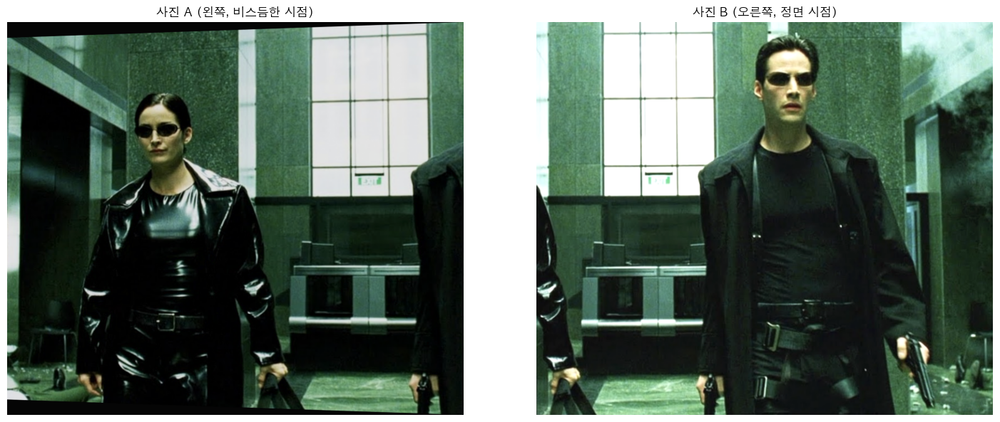

In [24]:
base = cv2.imread('sample.jpg')
assert base is not None, "sample.jpg를 찾을 수 없습니다."

h, w = base.shape[:2]

# (1) 좌우로 겹치게 분할
left_end = int(w * 0.65)
right_start = int(w * 0.35)
img1_raw = base[:, :left_end].copy()
img2 = base[:, right_start:].copy()

# (2) 왼쪽 사진(img1)에 약한 원근 왜곡 (살짝 비스듬한 시점에서 촬영된 효과)
# img1이 비스듬히 찍혔고 img2가 정면 시점이라는 시나리오
lh, lw = img1_raw.shape[:2]
src = np.float32([[0, 0], [lw-1, 0], [lw-1, lh-1], [0, lh-1]])
dst = np.float32([[0,         lh*0.04],   # 좌상 살짝 아래로
                  [lw-1,      0],          # 우상 그대로
                  [lw-1,      lh-1],       # 우하 그대로
                  [0,         lh*0.96]])   # 좌하 살짝 위로
H_warp = cv2.getPerspectiveTransform(src, dst)
img1 = cv2.warpPerspective(img1_raw, H_warp, (lw, lh))

# (3) 노출 차이 시뮬레이션: 두 사진의 밝기를 미세하게 다르게
img1 = cv2.convertScaleAbs(img1, alpha=0.92, beta=-5)
img2 = cv2.convertScaleAbs(img2, alpha=1.08, beta=8)

print(f"img1 (왼쪽) 크기: {img1.shape}")
print(f"img2 (오른쪽) 크기: {img2.shape}")
show([img1, img2], ['사진 A (왼쪽, 비스듬한 시점)', '사진 B (오른쪽, 정면 시점)'])


In [25]:
# 이후 단계에서 사용할 그레이스케일 버전 준비
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)


---
## 1. Harris 코너 검출

14강 슬라이드 7-9 재현. OpenCV `cornerHarris`는 구조 행렬 M의 응답 함수

$$R = \det(M) - k \cdot \text{trace}(M)^2$$

를 픽셀별로 계산해서 응답 맵을 반환합니다. R이 큰 양수인 곳이 코너 후보.


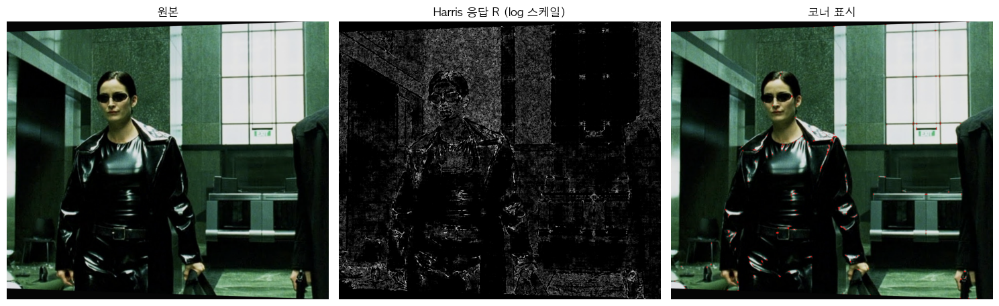

In [26]:
# cornerHarris 파라미터
# - blockSize: 구조 행렬 M을 계산할 윈도우 크기
# - ksize: Sobel 미분 커널 크기
# - k: 응답 함수의 감도 상수 (0.04 ~ 0.06)
gray_f = np.float32(gray1)
R = cv2.cornerHarris(gray_f, blockSize=3, ksize=3, k=0.04)

# R 값이 큰 픽셀에 빨간 점 표시 (임계값은 최댓값의 비율로)
img_harris = img1.copy()
img_harris[R > 0.01 * R.max()] = [0, 0, 255]

show([img1, np.log1p(np.clip(R, 0, None)), img_harris],
     ['원본', 'Harris 응답 R (log 스케일)', '코너 표시'])


### 비최대 억제 (NMS)

위 결과는 코너 하나 주변에 여러 픽셀이 함께 빨갛게 칠해진 상태. 14강 슬라이드 9의 NMS로 코너당 하나의 점만 남깁니다.


NMS 전 후보 픽셀 수: 3079
NMS 후 코너 점 수: 293


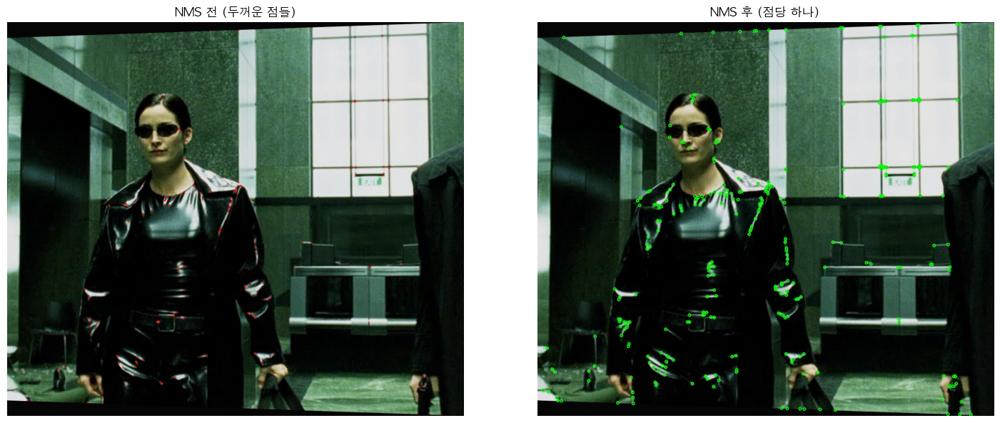

In [27]:
# 임계값으로 코너 후보 마스크 생성
threshold = 0.01 * R.max()
candidate_mask = (R > threshold).astype(np.uint8)

# dilate로 국소 최댓값 영역을 찾고, 그 안에서 R이 최대인 점만 남김
dilated = cv2.dilate(R, np.ones((7, 7)))
nms_mask = (R == dilated) & (R > threshold)

# NMS 결과 시각화
img_nms = img1.copy()
ys, xs = np.where(nms_mask)
for x, y in zip(xs, ys):
    cv2.circle(img_nms, (x, y), 4, (0, 255, 0), 2)

print(f"NMS 전 후보 픽셀 수: {candidate_mask.sum()}")
print(f"NMS 후 코너 점 수: {nms_mask.sum()}")
show([img_harris, img_nms], ['NMS 전 (두꺼운 점들)', 'NMS 후 (점당 하나)'])


---
## 2. SIFT 키포인트와 디스크립터

14강 슬라이드 11-13 재현. SIFT는 검출과 디스크립터 생성을 한 번에 수행.
- **키포인트**: 위치 (x, y) + 스케일 σ + 방향 θ
- **디스크립터**: 128차원 부동소수 벡터


In [28]:
sift = cv2.SIFT_create()

# detectAndCompute: 키포인트 검출 + 디스크립터 계산을 한 번에
kp1_sift, des1_sift = sift.detectAndCompute(gray1, None)
kp2_sift, des2_sift = sift.detectAndCompute(gray2, None)

print(f"img1 SIFT 키포인트: {len(kp1_sift)}, 디스크립터 shape: {des1_sift.shape}")
print(f"img2 SIFT 키포인트: {len(kp2_sift)}, 디스크립터 shape: {des2_sift.shape}")
print(f"디스크립터 dtype: {des1_sift.dtype} (부동소수 → L2 거리)")


img1 SIFT 키포인트: 1565, 디스크립터 shape: (1565, 128)
img2 SIFT 키포인트: 1533, 디스크립터 shape: (1533, 128)
디스크립터 dtype: float32 (부동소수 → L2 거리)


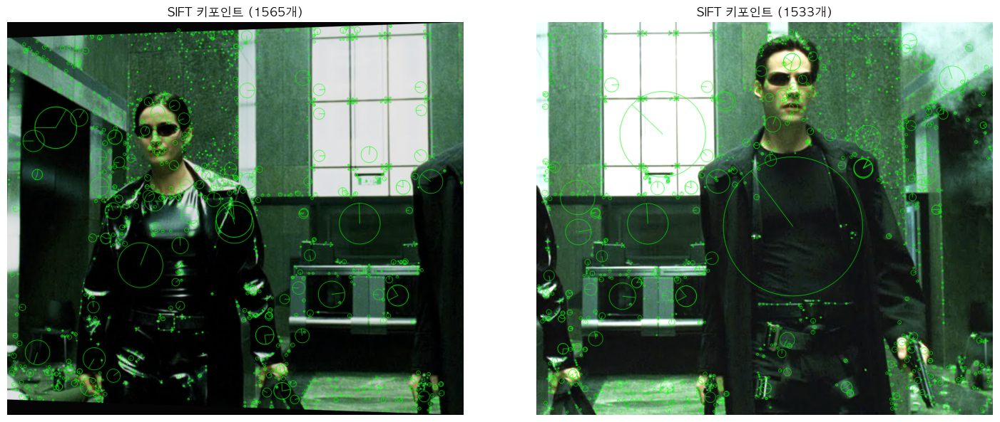

In [29]:
# 키포인트 시각화 (DRAW_RICH_KEYPOINTS: 스케일과 방향까지 표시)
img1_sift = cv2.drawKeypoints(img1, kp1_sift, None,
                               flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
                               color=(0, 255, 0))
img2_sift = cv2.drawKeypoints(img2, kp2_sift, None,
                               flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
                               color=(0, 255, 0))

show([img1_sift, img2_sift],
     [f'SIFT 키포인트 ({len(kp1_sift)}개)',
      f'SIFT 키포인트 ({len(kp2_sift)}개)'])


---
## 3. ORB 키포인트와 디스크립터

14강 슬라이드 14 재현. ORB는 FAST + 회전된 BRIEF의 결합.
- **디스크립터**: 256비트 이진 벡터 → 해밍 거리로 매칭 → SIFT보다 100배 빠름


img1 ORB 키포인트: 1500, 디스크립터 shape: (1500, 32)
디스크립터 dtype: uint8 (이진 → 해밍 거리)


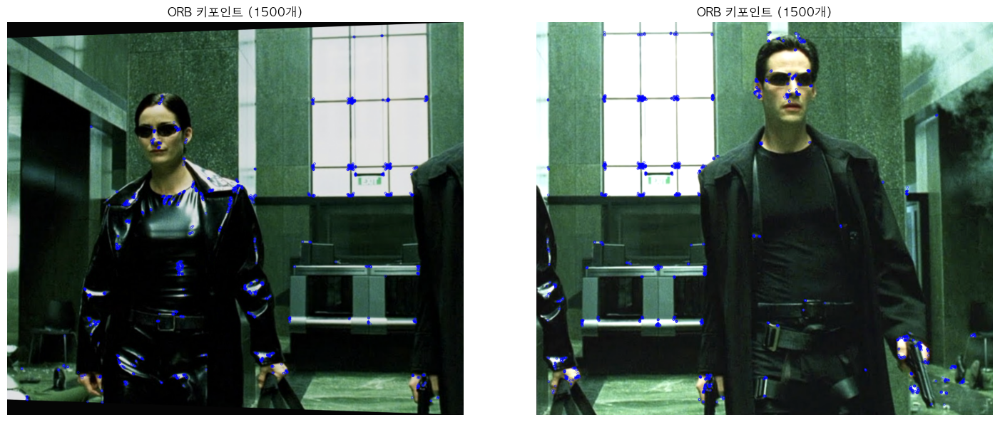

In [30]:
orb = cv2.ORB_create(nfeatures=1500)

kp1_orb, des1_orb = orb.detectAndCompute(gray1, None)
kp2_orb, des2_orb = orb.detectAndCompute(gray2, None)

print(f"img1 ORB 키포인트: {len(kp1_orb)}, 디스크립터 shape: {des1_orb.shape}")
print(f"디스크립터 dtype: {des1_orb.dtype} (이진 → 해밍 거리)")

img1_orb = cv2.drawKeypoints(img1, kp1_orb, None, color=(255, 0, 0))
img2_orb = cv2.drawKeypoints(img2, kp2_orb, None, color=(255, 0, 0))

show([img1_orb, img2_orb],
     [f'ORB 키포인트 ({len(kp1_orb)}개)',
      f'ORB 키포인트 ({len(kp2_orb)}개)'])


---
## 4. BFMatcher: 전수 탐색 매칭

15강 슬라이드 5 재현. 사진 A의 모든 디스크립터를 사진 B의 모든 디스크립터와 비교.

- SIFT (부동소수) → `NORM_L2`
- ORB (이진) → `NORM_HAMMING`


### 4-1. SIFT + BFMatcher (L2 거리)


전체 매칭 수: 1565
최단 거리: 8.60
최장 거리: 427.88


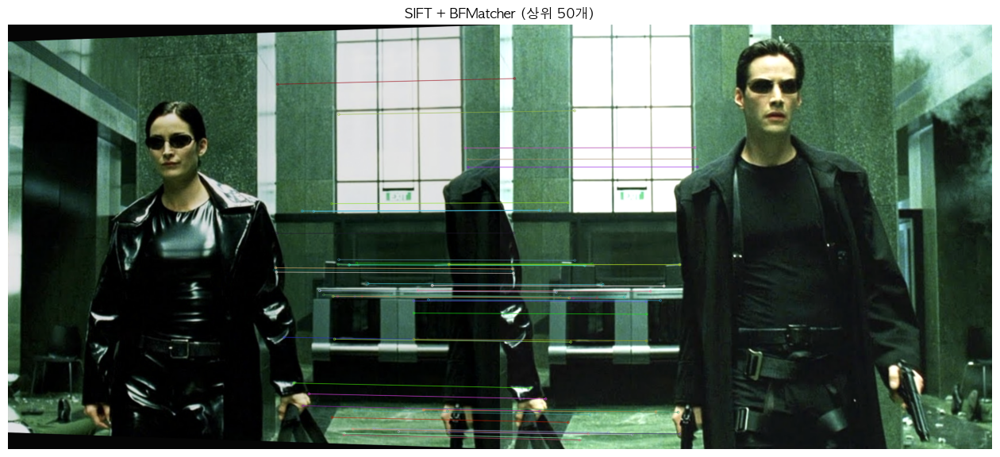

In [31]:
bf_sift = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
matches_sift = bf_sift.match(des1_sift, des2_sift)

# 거리 짧은 순으로 정렬 (좋은 매칭이 앞에)
matches_sift = sorted(matches_sift, key=lambda m: m.distance)
print(f"전체 매칭 수: {len(matches_sift)}")
print(f"최단 거리: {matches_sift[0].distance:.2f}")
print(f"최장 거리: {matches_sift[-1].distance:.2f}")

# 상위 50개만 시각화 (전부 그리면 너무 지저분)
img_match = cv2.drawMatches(img1, kp1_sift, img2, kp2_sift,
                             matches_sift[:50], None,
                             flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.figure(figsize=(16, 7))
plt.imshow(cv2.cvtColor(img_match, cv2.COLOR_BGR2RGB))
plt.title('SIFT + BFMatcher (상위 50개)')
plt.axis('off')
plt.show()


### 4-2. ORB + BFMatcher (해밍 거리, Cross Check)

15강 슬라이드 11의 Cross Check를 BFMatcher 옵션으로 켜기.


ORB Cross Check 후 매칭 수: 512


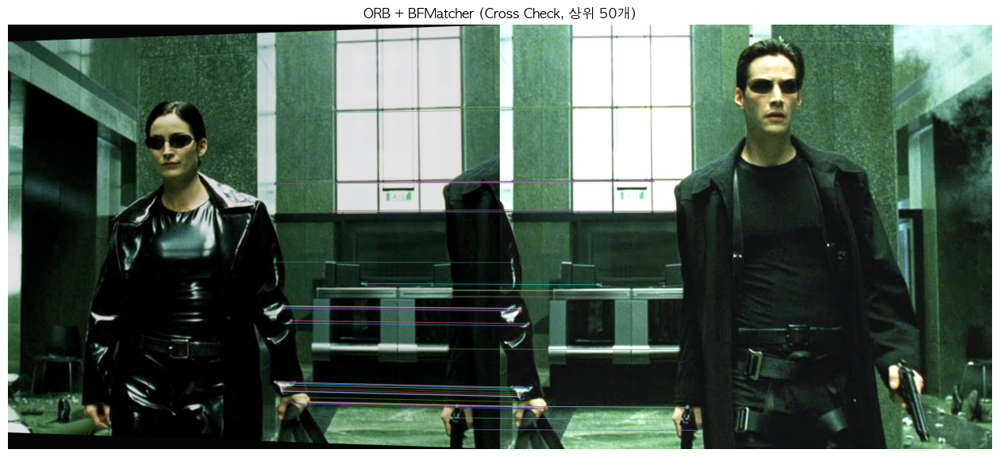

In [32]:
bf_orb = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches_orb = bf_orb.match(des1_orb, des2_orb)
matches_orb = sorted(matches_orb, key=lambda m: m.distance)
print(f"ORB Cross Check 후 매칭 수: {len(matches_orb)}")

img_match_orb = cv2.drawMatches(img1, kp1_orb, img2, kp2_orb,
                                 matches_orb[:50], None,
                                 flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.figure(figsize=(16, 7))
plt.imshow(cv2.cvtColor(img_match_orb, cv2.COLOR_BGR2RGB))
plt.title('ORB + BFMatcher (Cross Check, 상위 50개)')
plt.axis('off')
plt.show()


---
## 5. Lowe의 비율 테스트 (Ratio Test)

15강 슬라이드 10 재현. 가장 가까운 점과 두 번째 가까운 점의 거리 비율이 임계값보다 작을 때만 채택:

$$r = \frac{d_1}{d_2} < T \quad (\text{보통 } T = 0.7 \sim 0.8)$$

`knnMatch(k=2)`로 1등과 2등을 함께 얻은 뒤 직접 필터링.


비율 테스트 전: 1565개
비율 테스트 후 (r < 0.75): 397개
걸러진 매칭: 1168개 (74.6%)


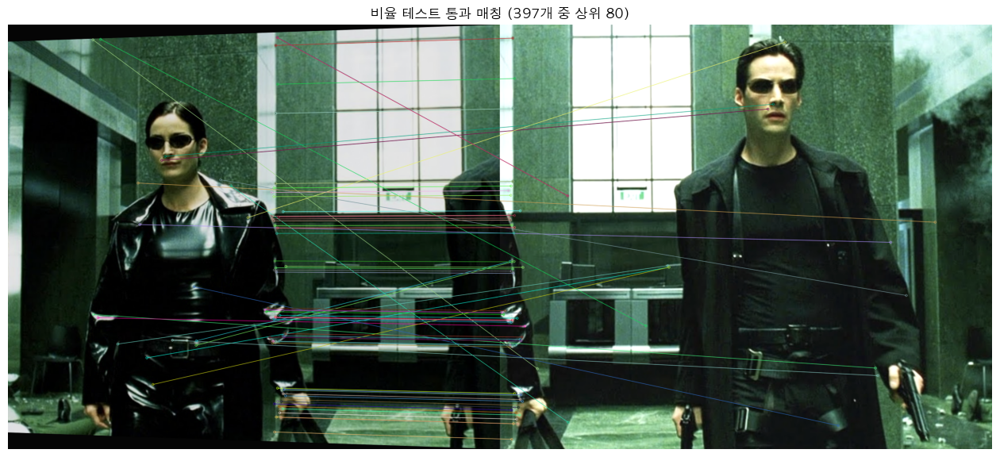

In [33]:
# crossCheck=False로 다시 만들어야 knnMatch 사용 가능
bf_sift_knn = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
knn_matches = bf_sift_knn.knnMatch(des1_sift, des2_sift, k=2)

# 비율 테스트
ratio_thresh = 0.75
good_matches = []
for m, n in knn_matches:
    if m.distance < ratio_thresh * n.distance:
        good_matches.append(m)

print(f"비율 테스트 전: {len(knn_matches)}개")
print(f"비율 테스트 후 (r < {ratio_thresh}): {len(good_matches)}개")
print(f"걸러진 매칭: {len(knn_matches) - len(good_matches)}개 "
      f"({100*(len(knn_matches)-len(good_matches))/len(knn_matches):.1f}%)")

img_good = cv2.drawMatches(img1, kp1_sift, img2, kp2_sift,
                            good_matches[:80], None,
                            flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.figure(figsize=(16, 7))
plt.imshow(cv2.cvtColor(img_good, cv2.COLOR_BGR2RGB))
plt.title(f'비율 테스트 통과 매칭 ({len(good_matches)}개 중 상위 80)')
plt.axis('off')
plt.show()


### 비율 분포 시각화

`d1/d2` 비율의 히스토그램. 정답 매칭은 비율이 낮은 쪽에 몰리고, 오매칭은 1에 가까운 쪽에 분포.


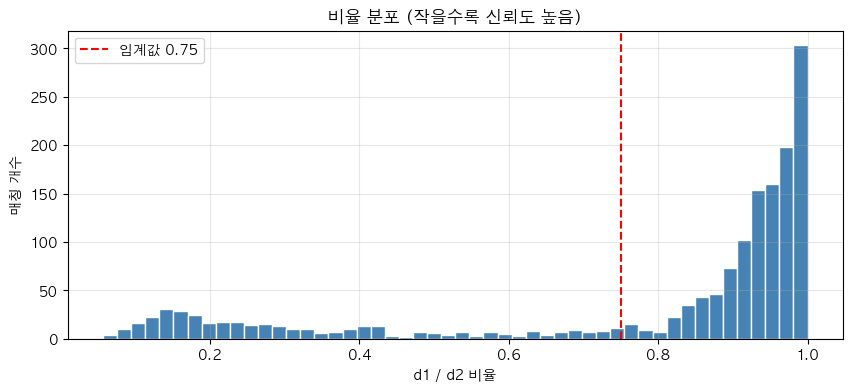

In [34]:
ratios = [m.distance / n.distance for m, n in knn_matches]

plt.figure(figsize=(10, 4))
plt.hist(ratios, bins=50, color='steelblue', edgecolor='white')
plt.axvline(ratio_thresh, color='red', linestyle='--',
            label=f'임계값 {ratio_thresh}')
plt.xlabel('d1 / d2 비율')
plt.ylabel('매칭 개수')
plt.title('비율 분포 (작을수록 신뢰도 높음)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


---
## 6. FLANN 매칭 (참고)

15강 슬라이드 6-7. 키포인트가 수천 개일 때 BFMatcher의 O(N×M) → FLANN의 O(N log M)으로 가속.

FLANN 결과도 같은 비율 테스트로 후처리합니다.


In [35]:
# SIFT는 부동소수 → KDTree 인덱스
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)

flann = cv2.FlannBasedMatcher(index_params, search_params)
flann_matches = flann.knnMatch(des1_sift, des2_sift, k=2)

flann_good = [m for m, n in flann_matches if m.distance < 0.75 * n.distance]
print(f"FLANN + 비율 테스트 후: {len(flann_good)}개")
print(f"(참고: BFMatcher + 비율 테스트는 {len(good_matches)}개)")


FLANN + 비율 테스트 후: 402개
(참고: BFMatcher + 비율 테스트는 397개)


---
## 7. RANSAC 호모그래피 추정

15강 슬라이드 13-14 재현. 비율 테스트로도 살아남은 잔존 outlier를 다수결로 추리고, inlier만으로 정밀한 H를 추정.

`cv2.findHomography(src, dst, cv2.RANSAC, threshold)`는 호모그래피 H와 inlier 마스크를 함께 반환.


In [36]:
# 매칭된 두 키포인트의 좌표 추출
src_pts = np.float32([kp1_sift[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
dst_pts = np.float32([kp2_sift[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

# RANSAC으로 호모그래피 추정
# ransacReprojThreshold: inlier로 인정할 재투영 오차 (픽셀)
H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC,
                              ransacReprojThreshold=3.0)
mask = mask.ravel().astype(bool)

print(f"입력 매칭: {len(good_matches)}개")
print(f"RANSAC inlier: {mask.sum()}개 ({100*mask.sum()/len(mask):.1f}%)")
print(f"RANSAC outlier: {(~mask).sum()}개")
print(f"\n추정된 호모그래피 H =")
print(H)


입력 매칭: 397개
RANSAC inlier: 351개 (88.4%)
RANSAC outlier: 46개

추정된 호모그래피 H =
[[ 1.04004041e+00  1.00554797e-04 -7.45381150e+02]
 [ 3.77010216e-02  1.08645701e+00 -5.21851033e+01]
 [ 6.21775959e-05  3.16898584e-07  1.00000000e+00]]


### Inlier vs Outlier 시각화

파란선이 RANSAC이 살린 inlier, 빨간선이 걸러낸 outlier.


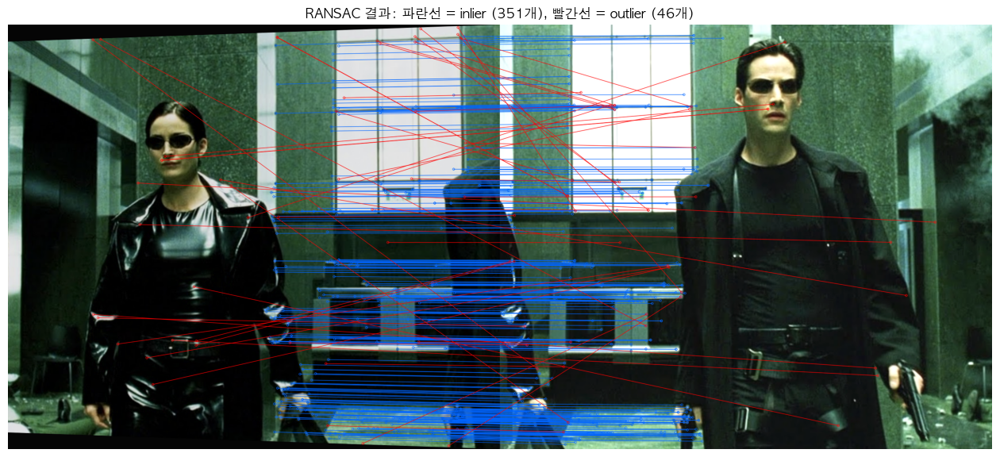

In [37]:
# inlier/outlier 분리해서 그리기
inlier_matches  = [m for m, keep in zip(good_matches, mask) if keep]
outlier_matches = [m for m, keep in zip(good_matches, mask) if not keep]

# inlier: 파란선
img_ransac = cv2.drawMatches(
    img1, kp1_sift, img2, kp2_sift,
    inlier_matches, None,
    matchColor=(255, 100, 0),       # BGR (파랑)
    singlePointColor=None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)
# outlier: 같은 캔버스에 빨간선으로 덧그리기
img_ransac = cv2.drawMatches(
    img1, kp1_sift, img2, kp2_sift,
    outlier_matches, img_ransac,
    matchColor=(0, 0, 255),         # BGR (빨강)
    singlePointColor=None,
    flags=cv2.DrawMatchesFlags_DRAW_OVER_OUTIMG |
          cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(16, 7))
plt.imshow(cv2.cvtColor(img_ransac, cv2.COLOR_BGR2RGB))
plt.title(f'RANSAC 결과: 파란선 = inlier ({mask.sum()}개), '
          f'빨간선 = outlier ({(~mask).sum()}개)')
plt.axis('off')
plt.show()


---
## 8. 파노라마 합성

추정된 H를 이용해 사진 A를 사진 B의 좌표계로 워핑한 뒤 한 캔버스에 합칩니다.

### 단계
1. 출력 캔버스 크기와 오프셋 계산 (음수 좌표가 나오지 않게)
2. 사진 A를 H로 워핑
3. 같은 캔버스에 사진 B를 그대로 붙이기
4. 겹치는 영역을 자연스럽게 블렌딩


In [38]:
def get_canvas_size(img1, img2, H):
    """img1을 H로 변환했을 때 img2와 합치는 데 필요한 캔버스 크기와 오프셋 계산"""
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]
    
    # img1의 네 모서리를 H로 변환
    corners1 = np.float32([[0, 0], [0, h1], [w1, h1], [w1, 0]]).reshape(-1, 1, 2)
    warped_corners1 = cv2.perspectiveTransform(corners1, H)
    
    # img2의 네 모서리는 그대로
    corners2 = np.float32([[0, 0], [0, h2], [w2, h2], [w2, 0]]).reshape(-1, 1, 2)
    
    # 모든 코너를 합쳐 bounding box 계산
    all_corners = np.concatenate([warped_corners1, corners2], axis=0)
    x_min, y_min = np.int32(all_corners.min(axis=0).ravel() - 0.5)
    x_max, y_max = np.int32(all_corners.max(axis=0).ravel() + 0.5)
    
    # 음수 좌표를 양수로 밀어주는 오프셋
    offset_x = -x_min
    offset_y = -y_min
    canvas_w = x_max - x_min
    canvas_h = y_max - y_min
    
    return canvas_w, canvas_h, offset_x, offset_y

canvas_w, canvas_h, off_x, off_y = get_canvas_size(img1, img2, H)
print(f"캔버스 크기: {canvas_w} x {canvas_h}, 오프셋: ({off_x}, {off_y})")


캔버스 크기: 2130 x 1297, 오프셋: (745, 52)


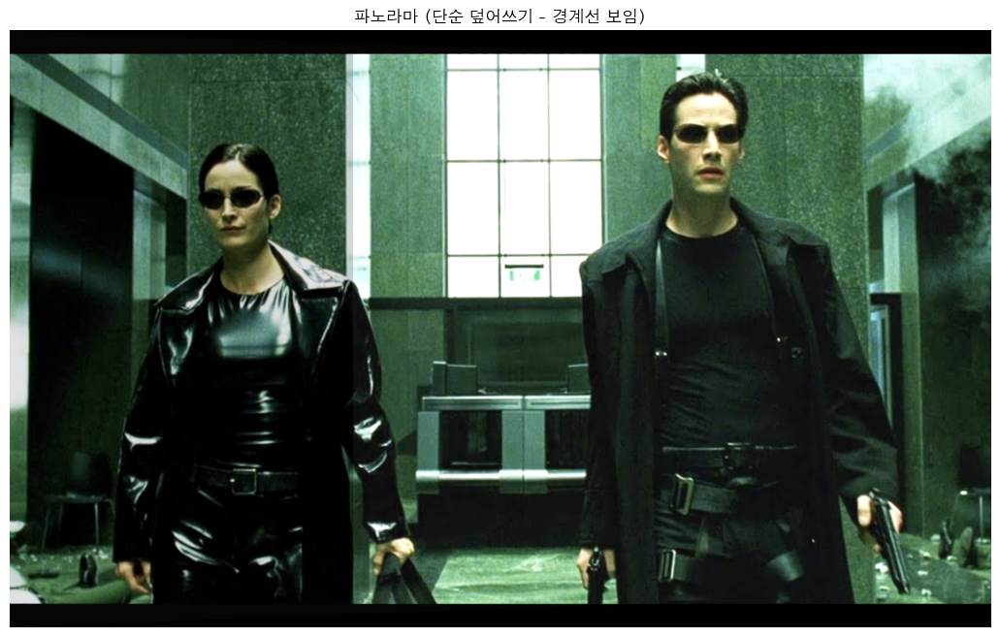

In [39]:
# 오프셋을 반영한 변환 행렬: T * H (먼저 H, 그 다음 오프셋만큼 평행이동)
T = np.array([[1, 0, off_x],
              [0, 1, off_y],
              [0, 0, 1]], dtype=np.float64)
H_offset = T @ H

# 사진 A를 캔버스 위로 워핑
panorama = cv2.warpPerspective(img1, H_offset, (canvas_w, canvas_h))

# 같은 캔버스에 사진 B를 그대로 붙이기 (오프셋 위치에)
h2, w2 = img2.shape[:2]
panorama_simple = panorama.copy()
panorama_simple[off_y:off_y+h2, off_x:off_x+w2] = img2

plt.figure(figsize=(16, 8))
plt.imshow(cv2.cvtColor(panorama_simple, cv2.COLOR_BGR2RGB))
plt.title('파노라마 (단순 덮어쓰기 - 경계선 보임)')
plt.axis('off')
plt.show()


### 8-2. 알파 블렌딩으로 경계 부드럽게

단순 덮어쓰기는 경계가 눈에 띕니다. 겹치는 영역에서 두 이미지의 픽셀을 가중 평균.


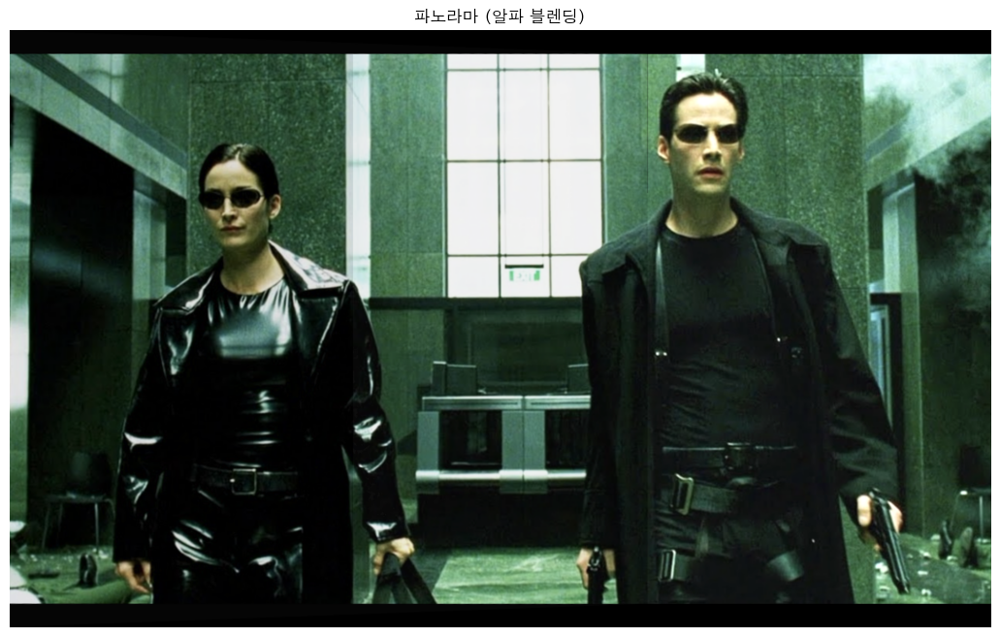

In [40]:
def blend_panorama(warped_a, img_b, off_x, off_y):
    """warped_a 캔버스 위에 img_b를 알파 블렌딩으로 합성"""
    canvas = warped_a.copy()
    h2, w2 = img_b.shape[:2]
    
    # 두 이미지가 있는 영역 마스크
    mask_a = (warped_a.sum(axis=2) > 0).astype(np.uint8)
    mask_b = np.zeros(canvas.shape[:2], dtype=np.uint8)
    mask_b[off_y:off_y+h2, off_x:off_x+w2] = 1
    
    overlap = mask_a & mask_b   # 겹치는 영역
    only_b  = mask_b & ~mask_a  # B만 있는 영역
    
    # B만 있는 영역은 B 픽셀 그대로
    b_canvas = np.zeros_like(canvas)
    b_canvas[off_y:off_y+h2, off_x:off_x+w2] = img_b
    canvas[only_b > 0] = b_canvas[only_b > 0]
    
    # 겹치는 영역은 50:50 블렌딩 (단순화)
    blended = cv2.addWeighted(warped_a, 0.5, b_canvas, 0.5, 0)
    canvas[overlap > 0] = blended[overlap > 0]
    
    return canvas

panorama_blended = blend_panorama(panorama, img2, off_x, off_y)

plt.figure(figsize=(16, 8))
plt.imshow(cv2.cvtColor(panorama_blended, cv2.COLOR_BGR2RGB))
plt.title('파노라마 (알파 블렌딩)')
plt.axis('off')
plt.show()


### 8-3. 거리 기반 가중치 블렌딩 (더 자연스럽게)

겹치는 영역에서 각 이미지의 중심으로부터 멀어질수록 가중치를 낮추면 경계가 거의 보이지 않습니다.


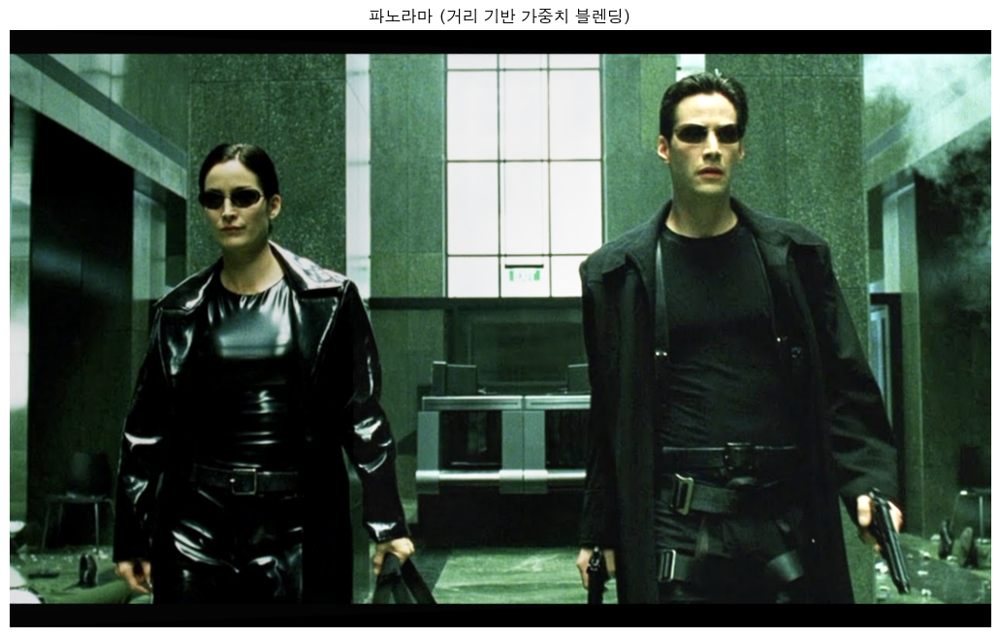

In [41]:
def distance_weighted_blend(warped_a, img_b, off_x, off_y):
    """각 이미지의 경계로부터의 거리를 가중치로 사용"""
    canvas_h, canvas_w = warped_a.shape[:2]
    h2, w2 = img_b.shape[:2]
    
    # B를 캔버스 크기로 옮긴 이미지
    b_canvas = np.zeros_like(warped_a)
    b_canvas[off_y:off_y+h2, off_x:off_x+w2] = img_b
    
    # 각 이미지의 유효 픽셀 마스크
    mask_a = (warped_a.sum(axis=2) > 0).astype(np.uint8)
    mask_b = (b_canvas.sum(axis=2) > 0).astype(np.uint8)
    
    # 거리 변환: 경계로부터 안쪽으로 들어갈수록 큰 값
    dist_a = cv2.distanceTransform(mask_a, cv2.DIST_L2, 3)
    dist_b = cv2.distanceTransform(mask_b, cv2.DIST_L2, 3)
    
    # 가중치 (분모 0 방지)
    total = dist_a + dist_b + 1e-6
    w_a = (dist_a / total)[..., None]   # (H, W, 1) 채널 브로드캐스트
    w_b = (dist_b / total)[..., None]
    
    blended = (warped_a.astype(np.float32) * w_a +
               b_canvas.astype(np.float32) * w_b)
    return np.clip(blended, 0, 255).astype(np.uint8)

panorama_smooth = distance_weighted_blend(panorama, img2, off_x, off_y)

plt.figure(figsize=(16, 8))
plt.imshow(cv2.cvtColor(panorama_smooth, cv2.COLOR_BGR2RGB))
plt.title('파노라마 (거리 기반 가중치 블렌딩)')
plt.axis('off')
plt.show()


### 세 가지 블렌딩 비교


In [ ]:
show([panorama_simple, panorama_blended, panorama_smooth],
     ['단순 덮어쓰기', '50:50 블렌딩', '거리 기반 블렌딩'],
     figsize=(18, 6))


---
## 정리

### 파이프라인 전체 흐름 (15강 슬라이드 15-16)

```
1. 입력 사진 A, B
2. 검출 + 디스크립터:    SIFT.detectAndCompute / ORB.detectAndCompute
3. 거리 기반 매칭:        BFMatcher.knnMatch (또는 FlannBasedMatcher)
4. 품질 필터링:           Lowe ratio test (+ cross check)
5. RANSAC 호모그래피:    cv2.findHomography(... cv2.RANSAC)
6. 워핑 + 블렌딩:         cv2.warpPerspective + alpha/distance blend
```

### 검출기·매처 조합

| 검출기 | 디스크립터 | 거리 함수 | 매처 옵션 |
|---|---|---|---|
| SIFT | 128차원 float | `NORM_L2` | BFMatcher 또는 FLANN(KDTree) |
| ORB | 256bit binary | `NORM_HAMMING` | BFMatcher(crossCheck) 또는 FLANN(LSH) |

### 필터링 단계의 역할

| 단계 | 무엇을 걸러내는가 |
|---|---|
| Lowe ratio test | 1등과 2등이 비슷한 모호한 매칭 |
| Cross check | 한쪽 방향에서만 1등인 매칭 |
| RANSAC | 위 단계 통과 후에도 남은 기하학적 outlier |

## 과제

1. SIFT와 ORB로 각각 같은 파노라마를 만들고 inlier 개수, 처리 속도, 결과 품질을 비교
2. `ratio_thresh`를 0.6 ~ 0.9로 바꿔가며 inlier 비율 변화 관찰
3. `ransacReprojThreshold`를 1, 3, 10픽셀로 바꿔가며 결과 비교
4. 본인이 직접 찍은 두 장의 사진(`sample.jpg`, `sample2.jpg`)으로 파노라마 만들기
5. 거리 기반 블렌딩에서 가중치 계산 방식을 바꿔보고 결과 비교

---

**한 학기 1-2부 마무리**. 다음 강의부터는 3부 (카메라 모델, 객체 추적, 딥러닝 연결).
